# Data Exploration


Environment Setup and Data Loading

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")

# Load the dataset
df = pd.read_csv('raw_data/mushrooms.csv')

# Display the first few rows
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


General Data Overview

In [7]:
# Check data dimensions and types
print(f"Dataset Shape: {df.shape}")
df.info()

# Summary statistics for categorical data
df.describe().T

Dataset Shape: (8124, 23)
<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   class                     8124 non-null   str  
 1   cap-shape                 8124 non-null   str  
 2   cap-surface               8124 non-null   str  
 3   cap-color                 8124 non-null   str  
 4   bruises                   8124 non-null   str  
 5   odor                      8124 non-null   str  
 6   gill-attachment           8124 non-null   str  
 7   gill-spacing              8124 non-null   str  
 8   gill-size                 8124 non-null   str  
 9   gill-color                8124 non-null   str  
 10  stalk-shape               8124 non-null   str  
 11  stalk-root                8124 non-null   str  
 12  stalk-surface-above-ring  8124 non-null   str  
 13  stalk-surface-below-ring  8124 non-null   str  
 14  stalk-color-above-ring   

,count,unique,top,freq
class,8124,2,e,4208
cap-shape,8124,6,x,3656
cap-surface,8124,4,y,3244
cap-color,8124,10,n,2284
bruises,8124,2,f,4748
odor,8124,9,n,3528
gill-attachment,8124,2,f,7914
gill-spacing,8124,2,c,6812
gill-size,8124,2,b,5612
gill-color,8124,12,b,1728


Target Variable Analysis

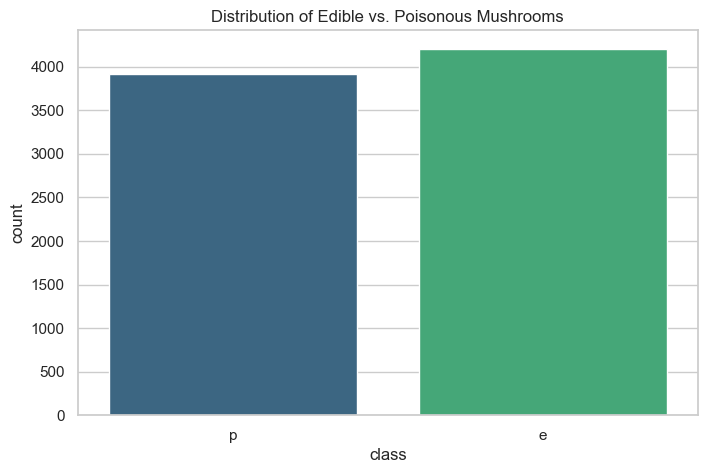

class
e    0.517971
p    0.482029
Name: proportion, dtype: float64


In [8]:
# Check for class balance
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='class', data=df, hue='class', palette='viridis', legend=False)
plt.title('Distribution of Edible vs. Poisonous Mushrooms')
plt.show()

# Precise counts
print(df['class'].value_counts(normalize=True))

#### Feature Inspection and Constant Columns

We check if any columns have only one unique value (zero variance), as they provide no predictive power.

In [9]:
unique_counts = df.nunique()
constant_columns = unique_counts[unique_counts == 1].index.tolist()

print(f"Constant columns to be dropped: {constant_columns}")


Constant columns to be dropped: ['veil-type']


We found that the only type of veil-type is p, which makes it useless. Thus, we are going to remove it in preprocessing step

#### Handling Hidden Missing Values
In this dataset, missing values in the stalk-root column are recorded as '?'. We need to quantify this.

Column 'stalk-root' has 2480 missing values represented as '?'


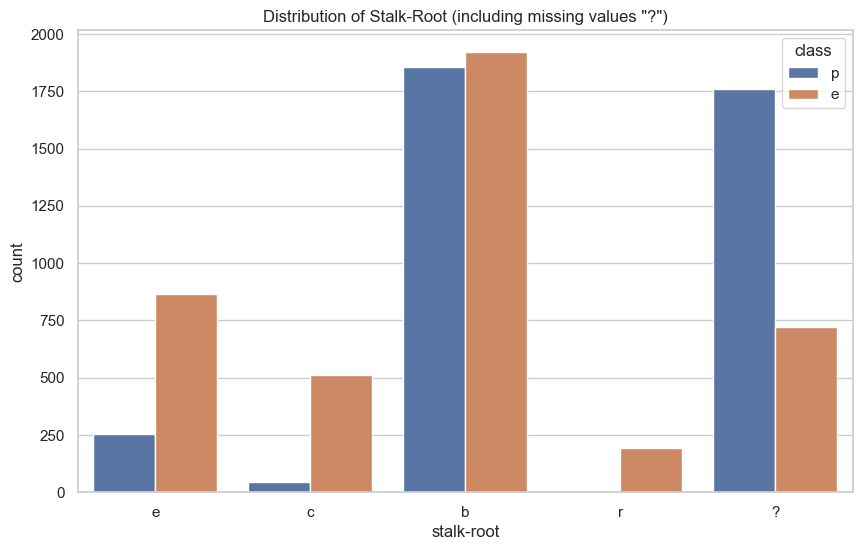

In [10]:
# Check for the '?' character in the dataset
for col in df.columns:
    null_count = len(df[df[col] == '?'])
    if null_count > 0:
        print(f"Column '{col}' has {null_count} missing values represented as '?'")

# Visualization of stalk-root distribution including '?'
plt.figure(figsize=(10, 6))
sns.countplot(x='stalk-root', data=df, hue='class')
plt.title('Distribution of Stalk-Root (including missing values "?")')
plt.show()

#### Visualizing Strong Predictors
We explore how specific features like odor correlate with the mushroom being poisonous or edible. This is crucial for understanding why models like Naive Bayes or Logistic Regression might perform well.

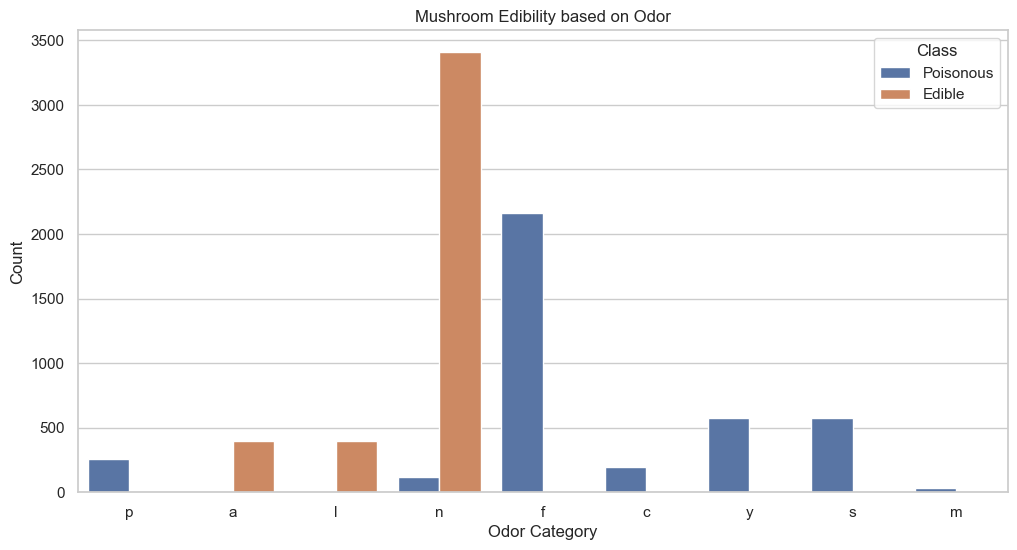

In [11]:
# Odor vs Class visualization
plt.figure(figsize=(12, 6))
sns.countplot(x='odor', hue='class', data=df)
plt.title('Mushroom Edibility based on Odor')
plt.xlabel('Odor Category')
plt.ylabel('Count')
plt.legend(title='Class', labels=['Poisonous', 'Edible'])
plt.show()

# List unique values for reference
# 'a': almond, 'l': anise, 'c': creosote, 'y': fishy, 'f': foul, 'm': musty, 'n': none, 'p': pungent, 's': spicy

#### Summary of Findings
Target Balance: The classes are relatively balanced, so accuracy is a valid metric.

Feature Redundancy: The veil-type column will be removed.

Missing Data: The stalk-root column contains '?' values which we will treat as a separate category.

Strong Correlations: Features like odor show significant separation between classes, indicating high potential for classification accuracy.